# 10 - Build EC → EC Network & First Analysis

This notebook builds a directed homogeneous citation network between EC cases,
and performs a focused first analysis using only the most interpretable metrics.

**Input:** `data/processed/ec_ec_case_matches.csv`

**Output:**
- `data/processed/network/ec_ec_nodes.csv`
- `data/processed/network/ec_ec_edges.csv`
- `data/processed/network/ec_ec_network.graphml`
- `data/processed/network/ec_ec_node_metrics.csv`

## 1. Imports and Configuration

In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("data/processed")
INPUT_PATH = DATA_DIR / "ec_ec_case_matches.csv"

OUT_DIR           = DATA_DIR / "network" / "ec_ec"
NODES_PATH        = OUT_DIR / "ec_ec_nodes.csv"
EDGES_PATH        = OUT_DIR / "ec_ec_edges.csv"
GRAPHML_PATH      = OUT_DIR / "ec_ec_network.graphml"
NODE_METRICS_PATH = OUT_DIR / "ec_ec_node_metrics.csv"

# Match-strength ordering (higher index = stronger)
STRENGTH_ORDER = {"weak": 0, "medium": 1, "strong": 2}

print("Configuration loaded.")

Configuration loaded.


## 2. Load CSV

In [36]:
df = pd.read_csv(INPUT_PATH, dtype=str).fillna("")

print(f"Rows loaded : {len(df):,}")
print(f"Columns     : {list(df.columns)}")
df.head(3)

Rows loaded : 485
Columns     : ['source_ec_case_number', 'source_case_title', 'source_date', 'source_type', 'source_document_type', 'source_document_url', 'target_ec_case_number', 'target_case_title', 'target_celex_no', 'matched_pattern', 'matched_text', 'match_strength', 'match_context', 'processing_status']


,source_ec_case_number,source_case_title,source_date,source_type,source_document_type,source_document_url,target_ec_case_number,target_case_title,target_celex_no,matched_pattern,matched_text,match_strength,match_context,processing_status
0,AT.40049,MasterCard inter-regional MIF monitoring,2019-04-29,AtStandardATCCase,decision,https://ec.europa.eu/competition/antitrust/cas...,AT.40153,E-book MFNs and related matters (Amazon),,(?<![A-Za-z0-9])(?:AT|IV|COMP)[\s./\-]*4[\s./\...,AT.40153,medium,EEA as “those countries participating in the E...,ok_pdf
1,AT.40049,MasterCard inter-regional MIF monitoring,2019-04-29,AtStandardATCCase,decision,https://ec.europa.eu/competition/antitrust/cas...,AT.29373,Visa International,,(?<![A-Za-z0-9])(?:AT|IV|COMP)[\s./\-]*2[\s./\...,IV/29.373,medium,to be paid in full in each statement cycle. 7...,ok_pdf
2,AT.40049,MasterCard inter-regional MIF monitoring,2019-04-29,AtStandardATCCase,decision,https://ec.europa.eu/competition/antitrust/cas...,AT.39398,Visa Inter-Regional MIF monitoring,,(?<![A-Za-z0-9])(?:AT|IV|COMP)[\s./\-]*3[\s./\...,AT.39398,medium,Mastercard consumer c redit card that is non -...,ok_pdf


## 3. Filter: Only Valid Matches

In [37]:
# Keep only rows with processing_status == "matched" (or "ok_pdf" / non-empty meaningful status)
# The file uses "ok_pdf" as the matched status based on the data
matched = df[df["processing_status"].str.strip().ne("") & df["processing_status"].str.strip().ne("no_match")].copy()

# Drop rows with missing source or target case numbers
matched = matched[
    matched["source_ec_case_number"].str.strip().ne("") &
    matched["target_ec_case_number"].str.strip().ne("")
].copy()

# Remove self-citations
matched = matched[
    matched["source_ec_case_number"].str.strip() != matched["target_ec_case_number"].str.strip()
].copy()

print(f"Rows after filtering: {len(matched):,}")
print(f"Unique processing_status values: {matched['processing_status'].unique()}")

Rows after filtering: 485
Unique processing_status values: <StringArray>
['ok_pdf']
Length: 1, dtype: str


## 4. Deduplicate to One Edge per Source-Target Pair

Each raw row represents one pattern match. Multiple rows may exist for the same
source-target pair (different passages, different patterns). We aggregate them into
one unique directed edge per `(source_ec_case_number, target_ec_case_number)` pair,
keeping useful aggregated attributes.

In [38]:
def best_strength(strengths: pd.Series) -> str:
    """Return the strongest match_strength value in a group."""
    ranked = strengths.map(lambda s: STRENGTH_ORDER.get(s, -1))
    best_idx = ranked.idxmax()
    return strengths.loc[best_idx]


edges_raw = (
    matched
    .groupby(["source_ec_case_number", "target_ec_case_number"], sort=False)
    .agg(
        match_count           = ("match_strength", "count"),
        best_match_strength   = ("match_strength", best_strength),
        all_match_strengths   = ("match_strength", lambda s: "|".join(s.unique())),
        example_match_context = ("match_context", "first"),
    )
    .reset_index()
)

print(f"Unique EC-EC pairs (edges): {len(edges_raw):,}")
edges_raw.head(3)

Unique EC-EC pairs (edges): 485


,source_ec_case_number,target_ec_case_number,match_count,best_match_strength,all_match_strengths,example_match_context
0,AT.40049,AT.40153,1,medium,medium,EEA as “those countries participating in the E...
1,AT.40049,AT.29373,1,medium,medium,to be paid in full in each statement cycle. 7...
2,AT.40049,AT.39398,1,medium,medium,Mastercard consumer c redit card that is non -...


## 5. Build Node Table

All EC cases that appear as source or target are collected into a single node table.
Source and target metadata are merged carefully so each case appears only once.

In [39]:
# ── Source node metadata ───────────────────────────────────────────────────────
src_meta = (
    matched[["source_ec_case_number", "source_case_title", "source_date",
             "source_type", "source_document_type"]]
    .drop_duplicates(subset="source_ec_case_number")
    .rename(columns={
        "source_ec_case_number": "case_number",
        "source_case_title"    : "label",
        "source_date"          : "date",
        "source_type"          : "source_type",
        "source_document_type" : "document_type",
    })
    .copy()
)
src_meta["celex_no"] = ""

# ── Target node metadata ───────────────────────────────────────────────────────
tgt_meta = (
    matched[["target_ec_case_number", "target_case_title", "target_celex_no"]]
    .drop_duplicates(subset="target_ec_case_number")
    .rename(columns={
        "target_ec_case_number": "case_number",
        "target_case_title"    : "label",
        "target_celex_no"      : "celex_no",
    })
    .copy()
)
tgt_meta["date"]          = ""
tgt_meta["source_type"]   = ""
tgt_meta["document_type"] = ""

# ── Merge: source takes priority for shared cases ─────────────────────────────
all_meta = pd.concat([src_meta, tgt_meta], ignore_index=True)
all_meta = all_meta.drop_duplicates(subset="case_number", keep="first")

ec_nodes = pd.DataFrame({
    "node_id"      : "ec:" + all_meta["case_number"],
    "node_type"    : "ec",
    "label"        : all_meta["label"].values,
    "case_number"  : all_meta["case_number"].values,
    "celex_no"     : all_meta["celex_no"].values,
    "date"         : all_meta["date"].values,
    "source_type"  : all_meta["source_type"].values,
    "document_type": all_meta["document_type"].values,
})

print(f"EC nodes: {len(ec_nodes):,}")
ec_nodes.head(5)

EC nodes: 300


,node_id,node_type,label,case_number,celex_no,date,source_type,document_type
0,ec:AT.40049,ec,MasterCard inter-regional MIF monitoring,AT.40049,,2019-04-29,AtStandardATCCase,decision
1,ec:AT.40153,ec,E-book MFNs and related matters (Amazon),AT.40153,,2017-05-04,AtStandardATCCase,decision
2,ec:AT.39168,ec,Fasteners,AT.39168,,2007-09-19,AtStandardATCCase,decision
3,ec:AT.41034,ec,Exclusion of AI competitors from WhatsApp,AT.41034,,2025-12-04,AtStandardATCCase,decision
4,ec:AT.39181,ec,Candle waxes,AT.39181,,2008-10-01,AtStandardATCCase,decision


## 6. Build Edge Table

In [40]:
edges = edges_raw.copy()
edges.insert(0, "source", "ec:" + edges["source_ec_case_number"])
edges.insert(1, "target", "ec:" + edges["target_ec_case_number"])

print(f"Edges: {len(edges):,}")
edges.head(3)

Edges: 485


,source,target,source_ec_case_number,target_ec_case_number,match_count,best_match_strength,all_match_strengths,example_match_context
0,ec:AT.40049,ec:AT.40153,AT.40049,AT.40153,1,medium,medium,EEA as “those countries participating in the E...
1,ec:AT.40049,ec:AT.29373,AT.40049,AT.29373,1,medium,medium,to be paid in full in each statement cycle. 7...
2,ec:AT.40049,ec:AT.39398,AT.40049,AT.39398,1,medium,medium,Mastercard consumer c redit card that is non -...


## 7. Build NetworkX Directed Graph

In [41]:
G = nx.DiGraph()

# Add EC nodes
for _, row in ec_nodes.iterrows():
    G.add_node(
        row["node_id"],
        node_type    =row["node_type"],
        label        =row["label"],
        case_number  =row["case_number"],
        celex_no     =row["celex_no"],
        date         =row["date"],
        source_type  =row["source_type"],
        document_type=row["document_type"],
    )

# Add edges
for _, row in edges.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        match_count          =int(row["match_count"]),
        best_match_strength  =row["best_match_strength"],
        all_match_strengths  =row["all_match_strengths"],
        example_match_context=str(row["example_match_context"])[:300],
    )

print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Graph: 300 nodes, 485 edges


## 8. Basic Statistics

In [42]:
print(f"EC nodes : {len(ec_nodes):,}")
print(f"Edges    : {len(edges):,}")
print(f"Is directed: {G.is_directed()}")

EC nodes : 300
Edges    : 485
Is directed: True


---
## 9. Network Structure Metrics

The sections below compute three structural properties of the EC → EC citation graph:
**reciprocity**, **weakly connected components**, and **strongly connected components**.
These describe the overall topology of the network before diving into node-level metrics.

### 9.1 Reciprocity

**What it measures:**
Reciprocity is the fraction of edges that are mutual — i.e., if case A cites case B,
does case B also cite case A? A value of 0 means no mutual citations; 1 means every
citation is reciprocated.

**Why it matters for this EC → EC citation network:**
In a legal citation network, high reciprocity would be unusual (decisions typically cite
earlier cases, not later ones). Low reciprocity confirms the expected temporal, hierarchical
structure of the citation graph. Any non-zero reciprocity may indicate cases that were
decided close in time and cross-reference each other.

In [43]:
reciprocity = nx.reciprocity(G)
print(f"Network reciprocity: {reciprocity:.4f}")
print(f"  → {reciprocity * 100:.2f}% of edges have a reciprocal counterpart")

Network reciprocity: 0.0330
  → 3.30% of edges have a reciprocal counterpart


### 9.2 Weakly Connected Components

**What it measures:**
A weakly connected component (WCC) is a maximal set of nodes that are connected when
edge directions are ignored. Two nodes belong to the same WCC if there is an undirected
path between them.

**Why it matters for this EC → EC citation network:**
WCCs reveal whether the EC citation graph forms one large connected cluster or splits into
several isolated sub-networks. A dominant large WCC means most EC cases are structurally
linked through the citation graph; small isolated components may represent niche or
peripheral citation clusters with no connection to the main body of EC antitrust decisions.

In [44]:
wccs = list(nx.weakly_connected_components(G))
wccs_sorted = sorted(wccs, key=len, reverse=True)

print(f"Number of weakly connected components : {len(wccs_sorted):,}")
print(f"Largest WCC size                       : {len(wccs_sorted[0]):,} nodes")
print(f"Nodes in largest WCC (% of total)      : {len(wccs_sorted[0]) / G.number_of_nodes() * 100:.1f}%")

wcc_summary = pd.DataFrame({
    "component_id": range(1, len(wccs_sorted) + 1),
    "size"        : [len(c) for c in wccs_sorted],
})

print("\nWeakly connected component sizes (top 20):")
display(wcc_summary.head(20))

Number of weakly connected components : 16
Largest WCC size                       : 259 nodes
Nodes in largest WCC (% of total)      : 86.3%

Weakly connected component sizes (top 20):


,component_id,size
0,1,259
1,2,5
2,3,4
3,4,4
4,5,4
5,6,3
6,7,3
7,8,2
8,9,2
9,10,2


### 9.3 Strongly Connected Components

**What it measures:**
A strongly connected component (SCC) is a maximal set of nodes where every node can
reach every other node *following edge directions*. In a directed citation graph, an SCC
larger than 1 means a group of cases that mutually cite each other (directly or indirectly).

**Why it matters for this EC → EC citation network:**
Because citations typically flow forward in time (older cases are cited by newer ones),
most SCCs are expected to be trivial (size 1). Any non-trivial SCC (size > 1) indicates
a cycle of mutual citations — cases that reference each other in a loop — which may
reflect cross-referencing decisions issued close in time or corrections/amendments.

In [45]:
sccs = list(nx.strongly_connected_components(G))
sccs_sorted = sorted(sccs, key=len, reverse=True)

print(f"Number of strongly connected components : {len(sccs_sorted):,}")
print(f"Largest SCC size                         : {len(sccs_sorted[0]):,} nodes")
print(f"Nodes in largest SCC (% of total)        : {len(sccs_sorted[0]) / G.number_of_nodes() * 100:.1f}%")
print(f"Non-trivial SCCs (size > 1)              : {sum(1 for c in sccs_sorted if len(c) > 1):,}")

scc_summary = pd.DataFrame({
    "component_id": range(1, len(sccs_sorted) + 1),
    "size"        : [len(c) for c in sccs_sorted],
})

print("\nStrongly connected component sizes (top 20):")
display(scc_summary.head(20))

Number of strongly connected components : 295
Largest SCC size                         : 4 nodes
Nodes in largest SCC (% of total)        : 1.3%
Non-trivial SCCs (size > 1)              : 3

Strongly connected component sizes (top 20):


,component_id,size
0,1,4
1,2,2
2,3,2
3,4,1
4,5,1
5,6,1
6,7,1
7,8,1
8,9,1
9,10,1


---
## 10. Visualisation (Top 50 Nodes)

A quick visual impression of the network using the 25 most-cited and 25 most-citing EC cases.
Nodes are coloured by in-degree (cited) vs out-degree (citing) role for orientation.

Subgraph: 48 nodes, 99 edges


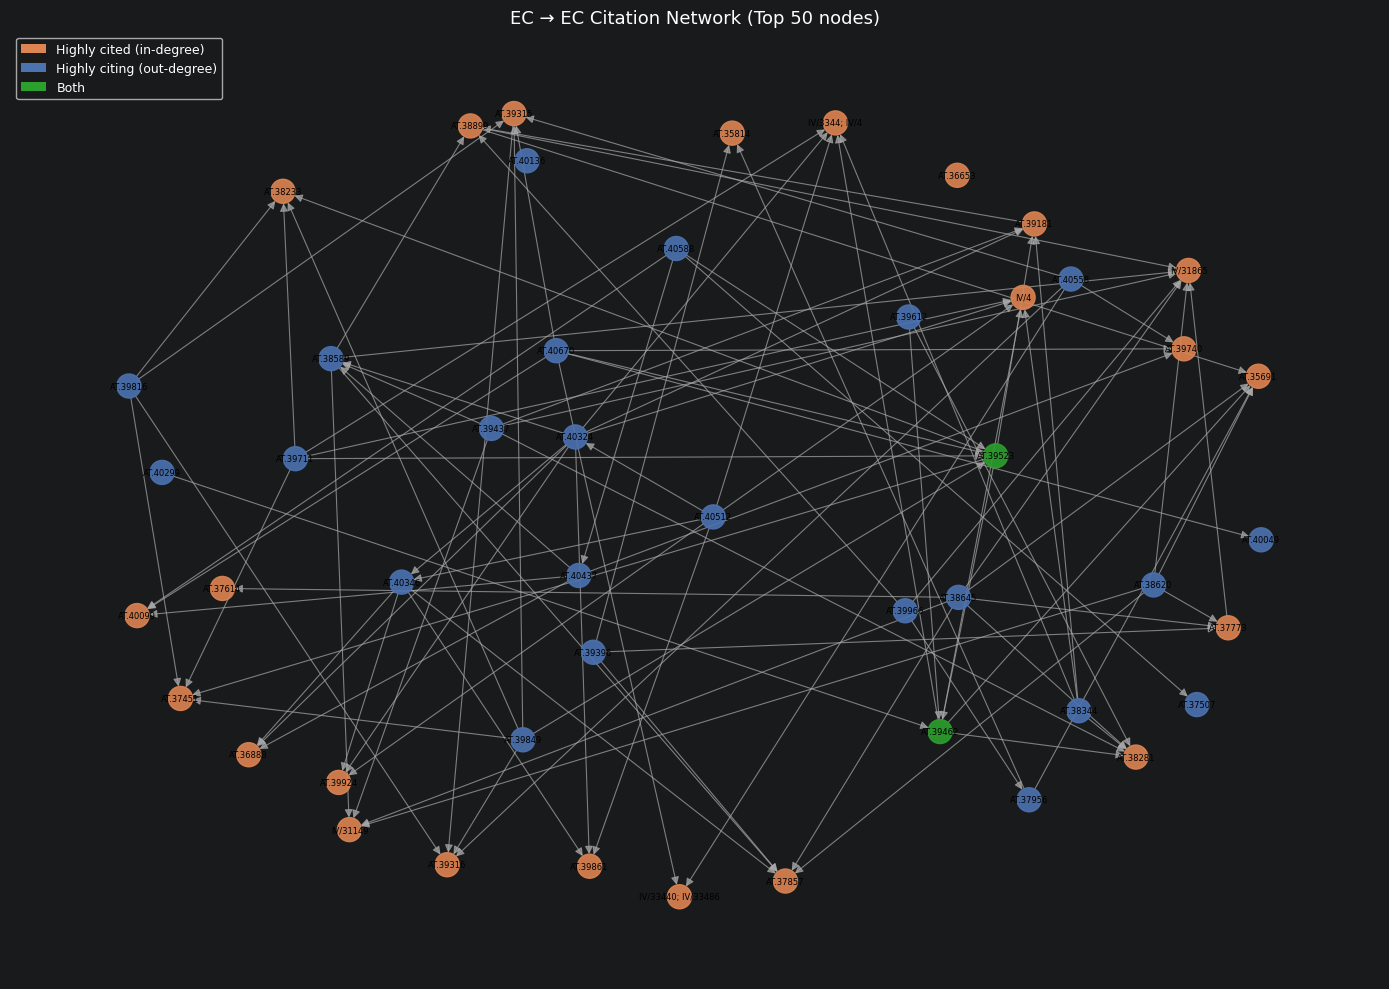

In [46]:
from matplotlib.patches import Patch

# Pre-compute degree series for subgraph selection
in_deg_series = pd.Series(
    dict(G.in_degree()),
    name="in_degree",
).sort_values(ascending=False)

out_deg_series = pd.Series(
    dict(G.out_degree()),
    name="out_degree",
).sort_values(ascending=False)

# Select top 25 most-cited and top 25 most-citing nodes
top_cited_ids  = in_deg_series.head(25).index.tolist()
top_citing_ids = out_deg_series.head(25).index.tolist()

sub_nodes = set(top_cited_ids) | set(top_citing_ids)
H = G.subgraph(sub_nodes).copy()

print(f"Subgraph: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")

# Colour: nodes that appear in top-cited get orange; top-citing get blue; both get green
color_map = []
for n in H.nodes():
    in_top  = n in top_cited_ids
    out_top = n in top_citing_ids
    if in_top and out_top:
        color_map.append("#2ca02c")   # green = both
    elif in_top:
        color_map.append("#DD8452")   # orange = highly cited
    else:
        color_map.append("#4C72B0")   # blue = highly citing

# Short labels (case number)
labels = {n: H.nodes[n].get("case_number", n) for n in H.nodes()}

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(H, seed=42, k=1.5)

nx.draw_networkx_nodes(H, pos, node_color=color_map, node_size=300, alpha=0.9, ax=ax)
nx.draw_networkx_edges(H, pos, edge_color="#aaaaaa", arrows=True,
                       arrowsize=12, width=0.8, alpha=0.7, ax=ax)
nx.draw_networkx_labels(H, pos, labels=labels, font_size=6, ax=ax)

legend_elements = [
    Patch(facecolor="#DD8452", label="Highly cited (in-degree)"),
    Patch(facecolor="#4C72B0", label="Highly citing (out-degree)"),
    Patch(facecolor="#2ca02c", label="Both"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_title("EC → EC Citation Network (Top 50 nodes)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 11. Network Analysis

The sections below compute the core node metrics for this directed EC citation graph.
Only the most interpretable metrics are included: **in-degree**, **out-degree**, and **PageRank**.

### 11.1 In-Degree and Out-Degree

**What it measures:**
- **In-degree** = number of incoming edges → how often an EC case is *cited by other EC cases*.
- **Out-degree** = number of outgoing edges → how many other EC cases a document *cites*.

**Why it matters for this citation network:**
In-degree is the most direct measure of an EC case's influence within the EC corpus:
the more other EC decisions reference it, the more foundational it is.
Out-degree reveals which EC documents draw most heavily on prior EC precedents.

**Most meaningful for:** both node types are EC cases, so both metrics are equally relevant.

In [47]:
# Compute in- and out-degree for every node
in_degree_all  = dict(G.in_degree())
out_degree_all = dict(G.out_degree())

# ── Top cited EC cases (by in-degree) ─────────────────────────────────────────
ec_in = (
    ec_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(in_degree=lambda df: df.index.map(in_degree_all))
    .sort_values("in_degree", ascending=False)
)

print("Top 20 most cited EC cases (in-degree):")
display(ec_in.head(20))

Top 20 most cited EC cases (in-degree):


,case_number,label,in_degree
node_id,,,
ec:IV/31865,IV/31865,PVC,12
ec:AT.35691,AT.35691,Pre-insulated pipe cartel,10
ec:IV/4,IV/4,GRUNDIG,9
ec:IV/3344; IV/4,IV/3344; IV/4,Grundig-Consten,9
ec:AT.38281,AT.38281,Raw Tobacco IT,9
ec:AT.37451,AT.37451,Price squeeze local loop Germany,8
ec:AT.38233,AT.38233,Wanadoo,8
ec:IV/31149,IV/31149,POLYPROPYLENE,6
ec:AT.39740,AT.39740,Google Search (Shopping),6


In [48]:
# ── Top citing EC cases (by out-degree) ───────────────────────────────────────
ec_out = (
    ec_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(out_degree=lambda df: df.index.map(out_degree_all))
    .sort_values("out_degree", ascending=False)
)

print("Top 20 most citing EC cases (out-degree):")
display(ec_out.head(20))

Top 20 most citing EC cases (out-degree):


,case_number,label,out_degree
node_id,,,
ec:AT.39437,AT.39437,TV and computer monitor tubes,19
ec:AT.38645,AT.38645,Methacrylates,19
ec:AT.38589,AT.38589,Heat stabilisers,18
ec:AT.40324,AT.40324,European Governments Bonds (EGB),13
ec:AT.39523,AT.39523,Slovak Telekom,12
ec:AT.39849,AT.39849,BEH gas,12
ec:AT.40512,AT.40512,Euro-denominated bonds (EDB),11
ec:AT.40437,AT.40437,Apple - App Store Practices (music streaming),11
ec:AT.40670,AT.40670,Google - Adtech and Data-related practices,10


### 11.2 PageRank

**What it measures:**
PageRank assigns a prestige score to each node based on the number and quality of incoming links.
A node receives a higher score if it is cited by nodes that are themselves highly cited.

**Why it matters for this citation network:**
Unlike raw in-degree, PageRank accounts for the *importance* of the citing document.
An EC case cited by many influential EC decisions will rank higher than one cited
by less prominent documents. This helps identify the most foundational EC precedents.

**Most meaningful for:** all EC nodes — identifies the most *prestigious* EC cases in the network.

In [49]:
pagerank = nx.pagerank(G, alpha=0.85)

# Top EC cases by PageRank
ec_pr = (
    ec_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree=lambda df: df.index.map(in_degree_all),
        pagerank =lambda df: df.index.map(pagerank),
    )
    .sort_values("pagerank", ascending=False)
)

print("Top 20 EC cases by PageRank:")
display(ec_pr.head(20))

Top 20 EC cases by PageRank:


,case_number,label,in_degree,pagerank
node_id,,,,
ec:IV/31865,IV/31865,PVC,12,0.016067
ec:AT.35691,AT.35691,Pre-insulated pipe cartel,10,0.011702
ec:AT.36653,AT.36653,Opel Nederland BV/General Motors Nederland BV,4,0.010948
ec:AT.38238,AT.38238,Raw Tobacco (ES),1,0.008260
ec:AT.40526,AT.40526,Thomas Cook (Holiday Pricing),4,0.007388
ec:AT.37614,AT.37614,Interbrew + Alken Maes,4,0.007331
ec:AT.38281,AT.38281,Raw Tobacco IT,9,0.007103
ec:AT.39740,AT.39740,Google Search (Shopping),6,0.007003
ec:AT.39915,AT.39915,Deutsche Bahn III,2,0.006785


### 11.3 Betweenness Centrality

**What it measures:**
Betweenness centrality counts how often a node lies on the shortest path between two other nodes.
A node with high betweenness acts as a *bridge* or *connector* within the network.

**Why it matters for this citation network:**
In the EC → EC citation network, a case with high betweenness is not just frequently cited —
it structurally connects otherwise separate clusters of EC decisions.
Such cases may represent pivotal precedents that link different areas of EC antitrust practice.

**Important note:** Betweenness is an additional structural metric, not the primary one.
In-degree and PageRank remain the main indicators of importance.
Betweenness highlights *bridge nodes* that may be overlooked by degree-based metrics alone.

In [50]:
betweenness = nx.betweenness_centrality(G, normalized=True)

# Top EC cases by betweenness
ec_bw = (
    ec_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree   =lambda df: df.index.map(in_degree_all),
        betweenness =lambda df: df.index.map(betweenness),
    )
    .sort_values("betweenness", ascending=False)
)

print("Top 20 EC cases by betweenness centrality:")
display(ec_bw.head(20))

Top 20 EC cases by betweenness centrality:


,case_number,label,in_degree,betweenness
node_id,,,,
ec:AT.39129,AT.39129,Power Transformers,3,0.002397
ec:AT.39523,AT.39523,Slovak Telekom,5,0.002319
ec:AT.38543,AT.38543,International Removal Services,3,0.002183
ec:AT.39462,AT.39462,Freight Forwarding,6,0.001992
ec:AT.38589,AT.38589,Heat stabilisers,3,0.001435
ec:AT.38069,AT.38069,PO/Copper plumbing tubes,2,0.001414
ec:AT.40437,AT.40437,Apple - App Store Practices (music streaming),2,0.000829
ec:AT.39309,AT.39309,LCD,2,0.000648
ec:AT.40324,AT.40324,European Governments Bonds (EGB),1,0.000525


---
## 12. Node-Level Metric Summary Table

All four core metrics are combined into a single node-level table for easy inspection and export.
Each row represents one EC node with its `in_degree`, `out_degree`, `pagerank`, and `betweenness`.

In [51]:
node_metrics = ec_nodes[["node_id", "label", "case_number"]].copy()

node_metrics["in_degree"]   = node_metrics["node_id"].map(in_degree_all)
node_metrics["out_degree"]  = node_metrics["node_id"].map(out_degree_all)
node_metrics["pagerank"]    = node_metrics["node_id"].map(pagerank)
node_metrics["betweenness"] = node_metrics["node_id"].map(betweenness)

print(f"Node metrics table: {len(node_metrics):,} rows")
display(node_metrics.sort_values("in_degree", ascending=False).head(20))

Node metrics table: 300 rows


,node_id,label,case_number,in_degree,out_degree,pagerank,betweenness
163,ec:IV/31865,PVC,IV/31865,12,0,0.016067,0.000000
148,ec:AT.35691,Pre-insulated pipe cartel,AT.35691,10,0,0.011702,0.000000
193,ec:IV/4,GRUNDIG,IV/4,9,0,0.005850,0.000000
191,ec:IV/3344; IV/4,Grundig-Consten,IV/3344; IV/4,9,0,0.005850,0.000000
46,ec:AT.38281,Raw Tobacco IT,AT.38281,9,1,0.007103,0.000258
297,ec:AT.37451,Price squeeze local loop Germany,AT.37451,8,0,0.006407,0.000000
13,ec:AT.38233,Wanadoo,AT.38233,8,2,0.006407,0.000337
287,ec:IV/31149,POLYPROPYLENE,IV/31149,6,0,0.005958,0.000000
168,ec:AT.39740,Google Search (Shopping),AT.39740,6,0,0.007003,0.000000
32,ec:AT.39462,Freight Forwarding,AT.39462,6,7,0.004832,0.001992


---
## 13. Summary Tables

### 13A. Top Cited EC Cases

Ranked by **in-degree** (raw citation count), also showing **PageRank** (prestige-weighted score).
These are the EC cases most frequently referenced by other EC documents.

In [52]:
top_ec_cited = (
    ec_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree=lambda df: df.index.map(in_degree_all),
        pagerank =lambda df: df.index.map(pagerank),
    )
    .sort_values(["in_degree", "pagerank"], ascending=False)
    .reset_index(drop=True)
)

print("Top 30 most cited EC cases (ranked by in-degree, then PageRank):")
display(top_ec_cited.head(30))

Top 30 most cited EC cases (ranked by in-degree, then PageRank):


,case_number,label,in_degree,pagerank
0,IV/31865,PVC,12,0.016067
1,AT.35691,Pre-insulated pipe cartel,10,0.011702
2,AT.38281,Raw Tobacco IT,9,0.007103
3,IV/3344; IV/4,Grundig-Consten,9,0.005850
4,IV/4,GRUNDIG,9,0.005850
5,AT.38233,Wanadoo,8,0.006407
6,AT.37451,Price squeeze local loop Germany,8,0.006407
7,AT.39740,Google Search (Shopping),6,0.007003
8,IV/31149,POLYPROPYLENE,6,0.005958
9,AT.39462,Freight Forwarding,6,0.004832


### 13B. Top Citing EC Cases

Ranked by **out-degree** (number of distinct EC cases cited).
These are the EC documents that draw most heavily on prior EC antitrust precedents.

In [53]:
top_ec_citing = (
    ec_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        out_degree=lambda df: df.index.map(out_degree_all),
    )
    .sort_values("out_degree", ascending=False)
    .reset_index(drop=True)
)

print("Top 30 most citing EC cases (ranked by out-degree):")
display(top_ec_citing.head(30))

Top 30 most citing EC cases (ranked by out-degree):


,case_number,label,out_degree
0,AT.39437,TV and computer monitor tubes,19
1,AT.38645,Methacrylates,19
2,AT.38589,Heat stabilisers,18
3,AT.40324,European Governments Bonds (EGB),13
4,AT.39523,Slovak Telekom,12
5,AT.39849,BEH gas,12
6,AT.40512,Euro-denominated bonds (EDB),11
7,AT.40437,Apple - App Store Practices (music streaming),11
8,AT.40670,Google - Adtech and Data-related practices,10
9,AT.40049,MasterCard inter-regional MIF monitoring,10


### 13C. Top EC Cases by Betweenness Centrality

Ranked by **betweenness centrality** — these are the EC cases that act as structural bridges
within the EC citation network, connecting otherwise separate clusters of decisions.
This is a supplementary structural view; in-degree and PageRank remain the primary metrics.

In [54]:
top_ec_betweenness = (
    ec_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        betweenness =lambda df: df.index.map(betweenness),
        in_degree   =lambda df: df.index.map(in_degree_all),
        pagerank    =lambda df: df.index.map(pagerank),
    )
    .sort_values("betweenness", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 EC cases by betweenness centrality:")
display(top_ec_betweenness.head(10))

Top 10 EC cases by betweenness centrality:


,case_number,label,betweenness,in_degree,pagerank
0,AT.39129,Power Transformers,0.002397,3,0.004597
1,AT.39523,Slovak Telekom,0.002319,5,0.003826
2,AT.38543,International Removal Services,0.002183,3,0.003643
3,AT.39462,Freight Forwarding,0.001992,6,0.004832
4,AT.38589,Heat stabilisers,0.001435,3,0.002746
5,AT.38069,PO/Copper plumbing tubes,0.001414,2,0.003353
6,AT.40437,Apple - App Store Practices (music streaming),0.000829,2,0.003480
7,AT.39309,LCD,0.000648,2,0.003572
8,AT.40324,European Governments Bonds (EGB),0.000525,1,0.002393
9,AT.40018,Car battery recycling,0.000491,3,0.003809


---
## 14. Export

In [55]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Node and edge tables
ec_nodes.to_csv(NODES_PATH, index=False, encoding="utf-8")
print(f"Saved {len(ec_nodes):,} nodes to: {NODES_PATH}")

edges.to_csv(EDGES_PATH, index=False, encoding="utf-8")
print(f"Saved {len(edges):,} edges to: {EDGES_PATH}")

# GraphML
nx.write_graphml(G, str(GRAPHML_PATH))
print(f"Saved GraphML to: {GRAPHML_PATH}")

# Node metrics
node_metrics.to_csv(NODE_METRICS_PATH, index=False, encoding="utf-8")
print(f"Saved node metrics to: {NODE_METRICS_PATH}")


Saved 300 nodes to: data\processed\network\ec_ec\ec_ec_nodes.csv
Saved 485 edges to: data\processed\network\ec_ec\ec_ec_edges.csv
Saved GraphML to: data\processed\network\ec_ec\ec_ec_network.graphml
Saved node metrics to: data\processed\network\ec_ec\ec_ec_node_metrics.csv
